In [1]:
!pip install ultralytics torch torchvision opencv-python pillow pyyaml kagglehub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.5 MB/s eta 0:00:00


In [18]:
import torch
from ultralytics import YOLO
from pathlib import Path
import yaml
import os
import kagglehub
import shutil
import cv2
import matplotlib.pyplot as plt
import random

In [10]:
!unzip -q BoneFractureYolo8.zip -d bone_fracture_data

In [11]:
dataset_root = Path("bone_fracture_data")

for item in dataset_root.iterdir():
    print(f"{item.name}")

yolo_path = dataset_root / "BoneFractureYolo8"

if not yolo_path.exists():
    yolo_path = dataset_root / "bone fracture detection.v4-v4.yolov8"

print(f"Датасет: {yolo_path.name}")

print("\nСтруктура датасета:")
for item in yolo_path.iterdir():
    if item.is_dir():
        print(f"{item.name}/")
        for subitem in item.iterdir():
            print(f"{subitem.name}/")
    else:
        print(f" {item.name}")

__MACOSX
BoneFractureYolo8
Датасет: BoneFractureYolo8

Структура датасета:
 README.dataset.txt
train/
labels/
images/
valid/
labels/
images/
 data.yaml
test/
labels/
images/


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
data_config = {
    'path': str(yolo_path.absolute()),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 1,
    'names': {0: 'fracture'}
}

with open('/content/data.yaml', 'w') as f:
    yaml.dump(data_config, f, sort_keys=False)

print(f"\ndata.yaml:")
print(f"  path: {data_config['path']}")
print(f"  train: {data_config['train']}")
print(f"  val: {data_config['val']}")
print(f"  nc: {data_config['nc']}")
print(f"  names: {data_config['names']}")

train_images = yolo_path / 'train' / 'images'
val_images = yolo_path / 'valid' / 'images'
test_images = yolo_path / 'test' / 'images'

print(f"  Train: {len(list(train_images.glob('*.*')))} изображений")
print(f"  Val: {len(list(val_images.glob('*.*')))} изображений")
print(f"  Test: {len(list(test_images.glob('*.*')))} изображений")


data.yaml:
  path: /content/bone_fracture_data/BoneFractureYolo8
  train: train/images
  val: valid/images
  nc: 1
  names: {0: 'fracture'}
  Train: 3631 изображений
  Val: 348 изображений
  Test: 169 изображений


In [14]:
model = YOLO('yolov8s.pt')

In [15]:
results = model.train(
    data='data.yaml',
    epochs=50,
    batch=16,
    imgsz=640,
    device=0,
    workers=4,
    patience=10,
    project='fracture_detection',
    name='exp1',
    exist_ok=True,
    lr0=0.001,
    optimizer='AdamW'
)

print("Обучение завершено")

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=10, perspective=0.0, plots=T

In [17]:
best_model_path = '/content/runs/detect/fracture_detection/exp1/weights/best.pt'
best_model = YOLO(best_model_path)

metrics = best_model.val(data='/content/data.yaml', split='test')

print(f"  mAP50 (IoU=0.5):     {metrics.box.map50:.4f}")
print(f"  mAP50-95:            {metrics.box.map:.4f}")
print(f"  Precision (mAP):     {metrics.box.mp:.4f}")
print(f"  Recall (mAP):        {metrics.box.mr:.4f}")
print("="*50)

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 279.2±102.8 MB/s, size: 11.3 KB)
val: Scanning /content/bone_fracture_data/BoneFractureYolo8/test/labels... 169 images, 86 backgrounds, 70 corrupt: 100% ━━━━━━━━━━━━ 169/169 1.2Kit/s 0.1s
val: /content/bone_fracture_data/BoneFractureYolo8/test/images/image1_1000_png.rf.a53c5e186c03961bf88075c6e3e94cf6.jpg: ignoring corrupt image/label: Label class 5 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/bone_fracture_data/BoneFractureYolo8/test/images/image1_1015_png.rf.9181f8eb07451331e22381bacb3a5bd2.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/bone_fracture_data/BoneFractureYolo8/test/images/image1_1035_png.rf.d7493a5653bc3628f7a1b1ec0eb5de85.jpg: ignoring corrupt image/label

Тестовое изображение: bone_fracture_data/BoneFractureYolo8/test/images/image1_852_png.rf.b721589a516459f110ab073a190f3f0f.jpg

image 1/1 /content/bone_fracture_data/BoneFractureYolo8/test/images/image1_852_png.rf.b721589a516459f110ab073a190f3f0f.jpg: 384x640 (no detections), 51.7ms
Speed: 2.7ms preprocess, 51.7ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


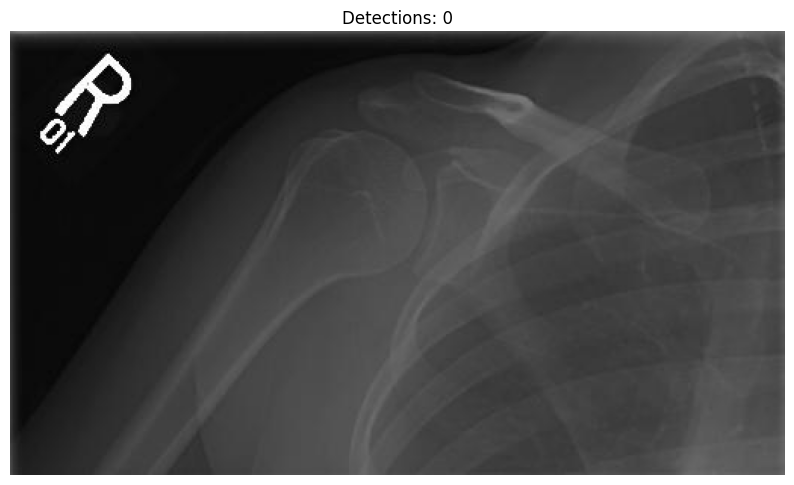


Переломов не обнаружено


In [44]:
test_dir = yolo_path / 'test' / 'images'
test_images = list(test_dir.glob('*.*'))

if test_images:
    test_img = str(random.choice(test_images))
    print(f"Тестовое изображение: {test_img}")

    results = best_model(test_img, conf=0.25)

    annotated_img = results[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title(f"Detections: {len(results[0].boxes)}")
    plt.show()

    if len(results[0].boxes) > 0:
        print(f"\nНайдено {len(results[0].boxes)} переломов:")
        for i, box in enumerate(results[0].boxes, 1):
            conf = box.conf[0].item()
            print(f"  {i}. Уверенность: {conf:.2%}")
    else:
        print("\nПереломов не обнаружено")
else:
    print("Тестовые изображения не найдены")

In [46]:
from google.colab import files
files.download('/content/runs/detect/fracture_detection/exp1/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>